# VisaRisk — Visa Certification Prediction

Predicts U.S. visa certification outcomes (Certified / Denied) using ensemble classifiers with SMOTE / undersampling and hyperparameter tuning.

**Target:** `case_status` (1 = Certified, 0 = Denied)

## Business Context

US employers across industries face a persistent challenge: filling specialized roles that cannot be met by the domestic workforce alone. To address this, the Immigration and Nationality Act (INA) allows employers to sponsor foreign workers for temporary or permanent positions, provided they can demonstrate a genuine labor shortage at competitive wages.

The Office of Foreign Labor Certification (OFLC) administers this process. For each application, OFLC must verify that hiring a foreign worker will not undercut wages or displace qualified US workers. When those conditions are met, OFLC issues a certification — effectively a greenlight for the employer to proceed with the visa sponsorship.

The volume of applications has grown steadily year over year, creating a backlog that strains manual review capacity. A data-driven approach that identifies the key drivers of certification outcomes can help OFLC prioritize cases, reduce processing time, and allocate reviewer resources more effectively.

## Objective

The growing volume of US work visa applications — nearly 776,000 in FY 2016 alone, up 9% year-over-year — has made manual case review unsustainable at scale.

This project builds a binary classification model to predict whether a visa application will be **Certified** or **Denied** based on applicant and employer attributes. The model serves three business goals:

* **Reduce processing time** by identifying high-probability certified cases for fast-track review
* **Surface key drivers** of certification so OFLC can set transparent, evidence-based criteria for applicants and employers
* **Balance false approvals and false denials** — a false approval wastes review resources; a false denial costs the economy skilled labor. This trade-off justifies F1 score as the primary evaluation metric.

## Data Description

The dataset contains 25,480 visa applications with attributes describing both the applicant and the sponsoring employer.

|-------------------------|------------------------------------------------------------------------------------------------|
| Feature                 | Description                                                                                    |
|-------------------------|------------------------------------------------------------------------------------------------|
| `case_id`               | Unique identifier for each visa application                                                    |
| `continent`             | Continent of origin of the applicant                                                           |
| `education_of_employee` | Highest education level<br>(High School / Bachelor's / Master's / Doctorate)                   |
| `has_job_experience`    | Whether the applicant has prior job experience (Y / N)                                         |
| `requires_job_training` | Whether the role requires job training (Y / N)                                                 |
| `no_of_employees`       | Total headcount at the sponsoring company                                                      |
| `yr_of_estab`           | Year the sponsoring company was established                                                    |
| `region_of_employment`  | US region where the foreign worker will be employed                                            |
| `prevailing_wage`       | Average wage for the same occupation and area;<br>protects against underpaying foreign workers |
| `unit_of_wage`          | Wage frequency (Hourly / Weekly / Monthly / Yearly)                                            |
| `full_time_position`    | Full-time (Y) or part-time (N) position                                                        |
| `case_status`           | **Target** — Certified (1) or Denied (0)                                                       |
|-------------------------|------------------------------------------------------------------------------------------------|


In [1]:
%matplotlib inline

import sys, pathlib
# Add project root to path so src/ and configs/ are importable
sys.path.insert(0, str(pathlib.Path.cwd()))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split

pd.set_option("display.max_columns", None)
pd.set_option("display.float_format", lambda x: "%.3f" % x)

# Project modules
from src.viz_utils import histogram_boxplot, labeled_barplot, stacked_barplot, distribution_plot_wrt_target
from src.preprocessing import load_data, preprocess, encode_features
from src.model_trainer import get_base_models, train_and_compare, apply_smote, apply_undersampling, tune_random, tune_grid
from src.evaluate import model_performance_classification_sklearn, confusion_matrix_sklearn, compare_models, select_best_model, plot_feature_importance, save_model
from configs.model_params import GBM_PARAMS, GBM_PARAMS_WIDE, ADA_PARAMS, XGB_PARAMS, XGB_PARAMS_UNDER

from sklearn.ensemble import GradientBoostingClassifier, AdaBoostClassifier
from xgboost import XGBClassifier


## 1. Load & Inspect Data

In [2]:
data = load_data()   # reads data/EasyVisa.csv
print(data.shape[0],"rows and",data.shape[1],"columns of data")
data.head()

25480 rows and 12 columns of data


,case_id,continent,education_of_employee,has_job_experience,requires_job_training,no_of_employees,yr_of_estab,region_of_employment,prevailing_wage,unit_of_wage,full_time_position,case_status
0,EZYV01,Asia,High School,N,N,14513,2007,West,592.203,Hour,Y,Denied
1,EZYV02,Asia,Master's,Y,N,2412,2002,Northeast,83425.650,Year,Y,Certified
2,EZYV03,Asia,Bachelor's,N,Y,44444,2008,West,122996.860,Year,Y,Denied
3,EZYV04,Asia,Bachelor's,N,N,98,1897,West,83434.030,Year,Y,Denied
4,EZYV05,Africa,Master's,Y,N,1082,2005,South,149907.390,Year,Y,Certified


*Observation:*
*   `wage` has decimal up to four places in some case. Investigate further to rule out typo during entry
*   `unit_of_wage` has Hour(ly) and Year(ly). Convert into year or monthly units

In [3]:
data.info()

<class 'pandas.DataFrame'>
RangeIndex: 25480 entries, 0 to 25479
Data columns (total 12 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   case_id                25480 non-null  str    
 1   continent              25480 non-null  str    
 2   education_of_employee  25480 non-null  str    
 3   has_job_experience     25480 non-null  str    
 4   requires_job_training  25480 non-null  str    
 5   no_of_employees        25480 non-null  int64  
 6   yr_of_estab            25480 non-null  int64  
 7   region_of_employment   25480 non-null  str    
 8   prevailing_wage        25480 non-null  float64
 9   unit_of_wage           25480 non-null  str    
 10  full_time_position     25480 non-null  str    
 11  case_status            25480 non-null  str    
dtypes: float64(1), int64(2), str(9)
memory usage: 2.3 MB


In [4]:
print("Duplicates:", data.duplicated().sum())
data.describe().T

Duplicates: 0


,count,mean,std,min,25%,50%,75%,max
no_of_employees,25480.000,5667.043,22877.929,-26.000,1022.000,2109.000,3504.000,602069.000
yr_of_estab,25480.000,1979.410,42.367,1800.000,1976.000,1997.000,2005.000,2016.000
prevailing_wage,25480.000,74455.815,52815.942,2.137,34015.480,70308.210,107735.513,319210.270


* The numerical summary reflects mixed wage units (hourly/weekly/monthly/yearly) — these figures are not directly comparable until normalized to annual in the preprocessing step.
* After normalization, average annual wages are approximately 74,000 dollars. The range spans from 53,000 to 319,000 dollars.
* We will revisit after adjusting for the different wage units.

## 2. Exploratory Data Analysis

### 2.1 Univariate — Continuous Features

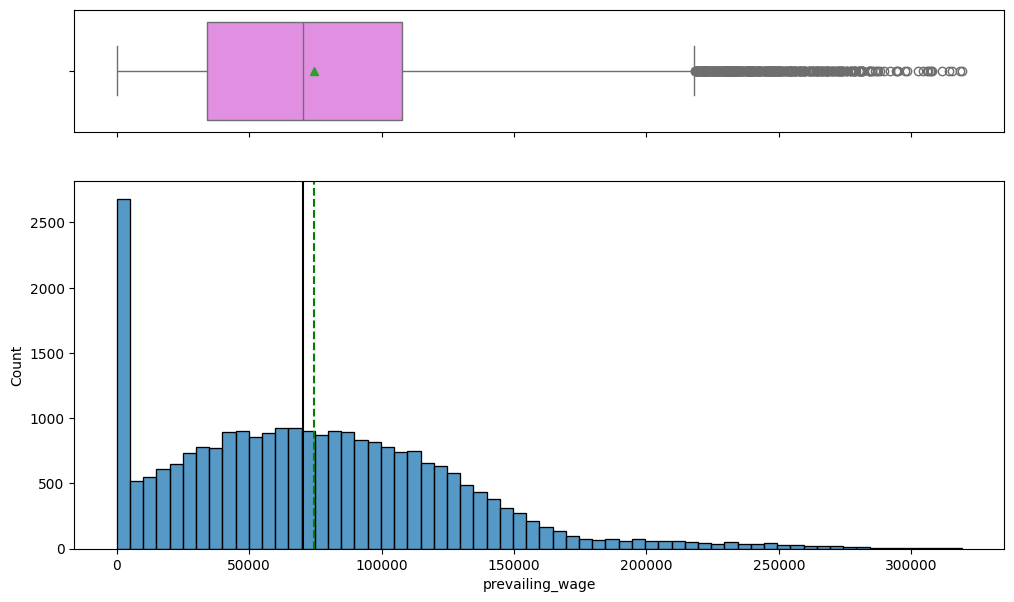

In [5]:
histogram_boxplot(data, "prevailing_wage")

* right-skewed
* 80K, with many outliers in the 300k+ range



--- unit_of_wage = Hour ---


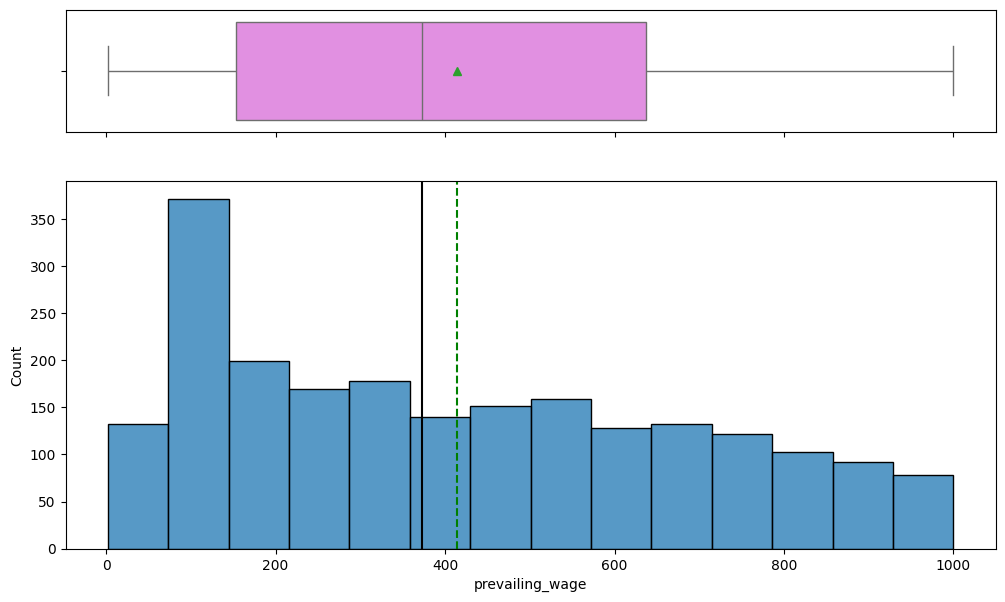


--- unit_of_wage = Year ---


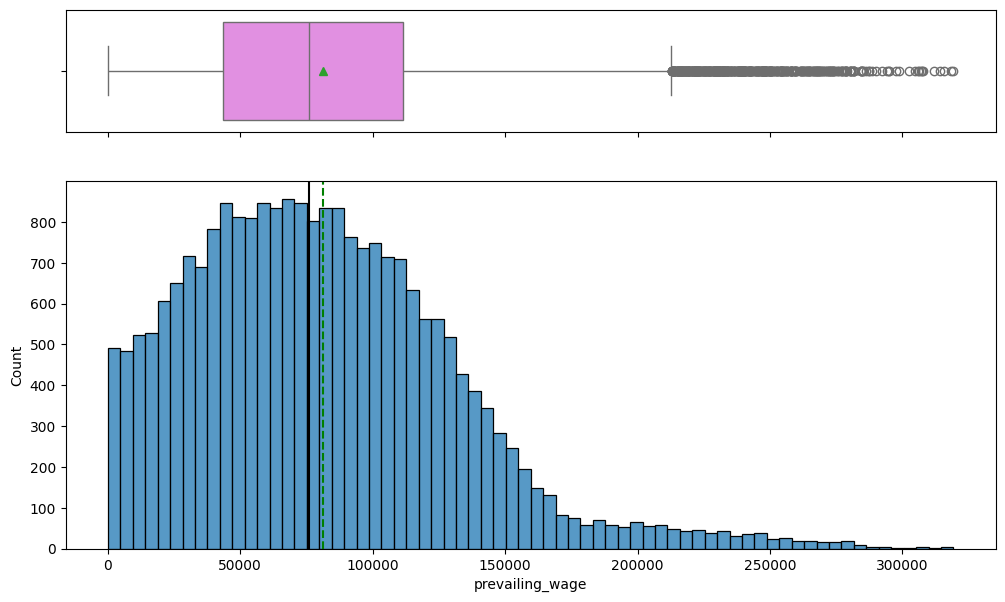


--- unit_of_wage = Week ---


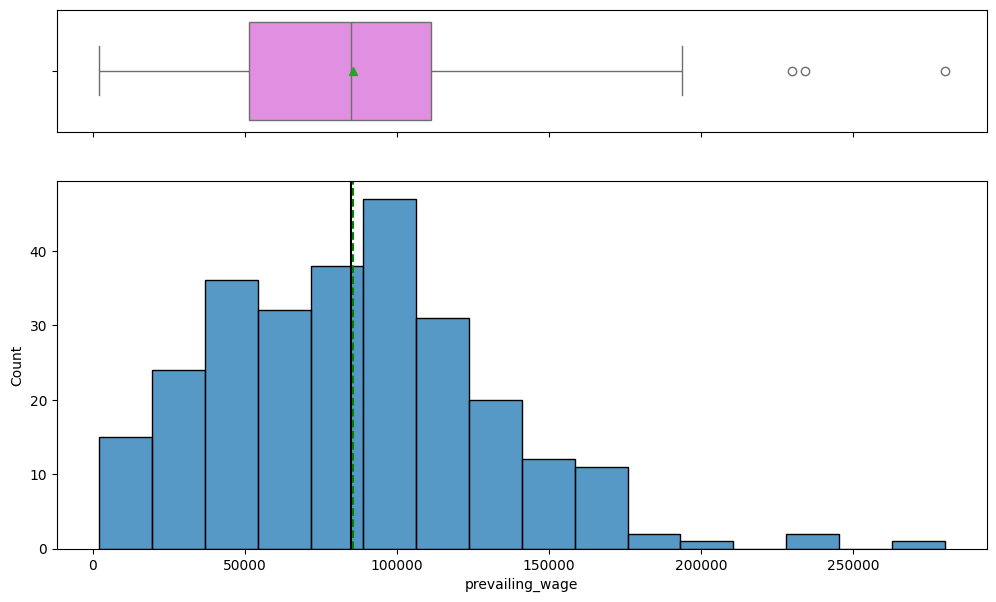


--- unit_of_wage = Month ---


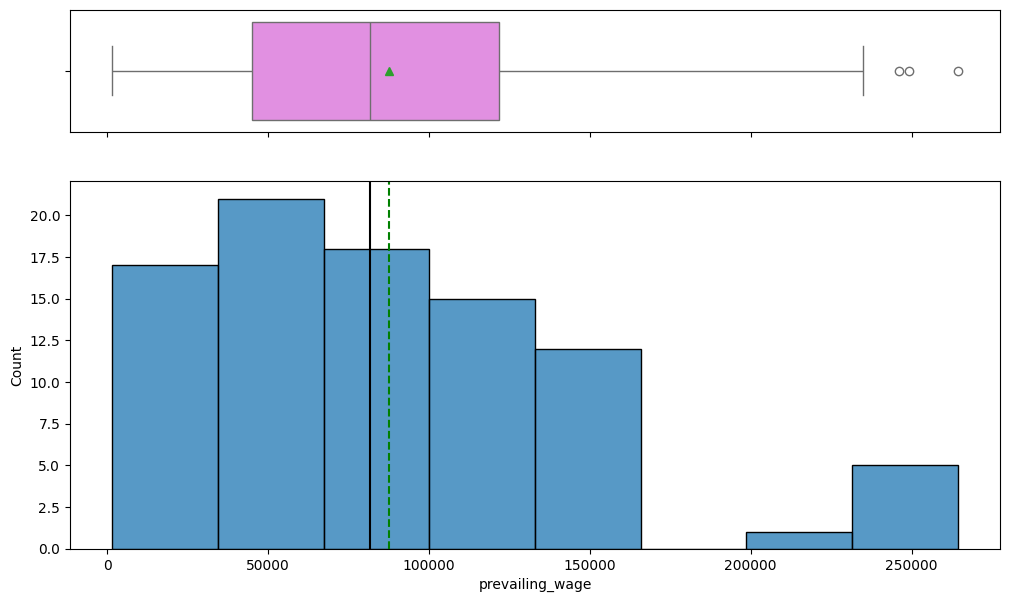

In [6]:
# Wage distribution by unit of measurement
for unit in data["unit_of_wage"].unique():
    print(f"\n--- unit_of_wage = {unit} ---")
    histogram_boxplot(data[data["unit_of_wage"] == unit], "prevailing_wage")

**Hourly wages:** right-skewed with a few high outliers; retained as outliers were certified.

**Weekly / Monthly wages:** similar distributions with few outliers; outliers were certified so left as-is.

**Yearly wages:** right-skewed with many outliers; retained — high wages represent real market conditions and the outliers were largely certified.

> High wages combined with High School education warrants further investigation — may represent entrepreneurs or specialty trade workers who tend to get certified despite lower formal education.

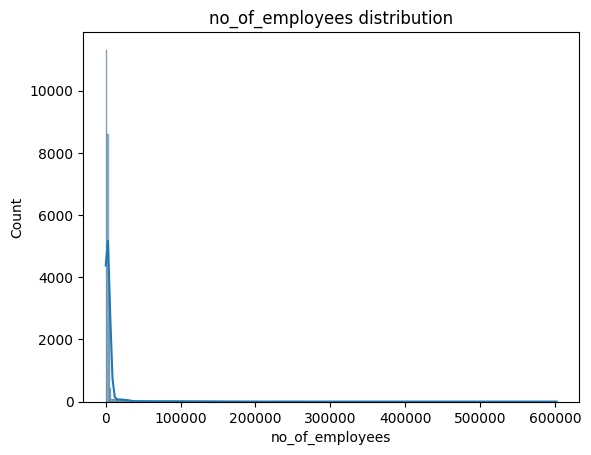

In [7]:
sns.histplot(data["no_of_employees"], kde=True)
plt.title("no_of_employees distribution")
plt.show()

* no_of_employees is severely right-skew

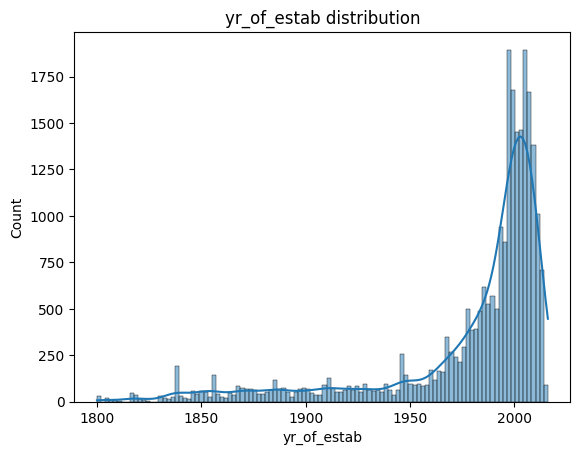

In [8]:
sns.histplot(data["yr_of_estab"], kde=True)
plt.title("yr_of_estab distribution")
plt.show()

* yr_of_estab is left-skewed

### 2.2 Univariate — Categorical Features

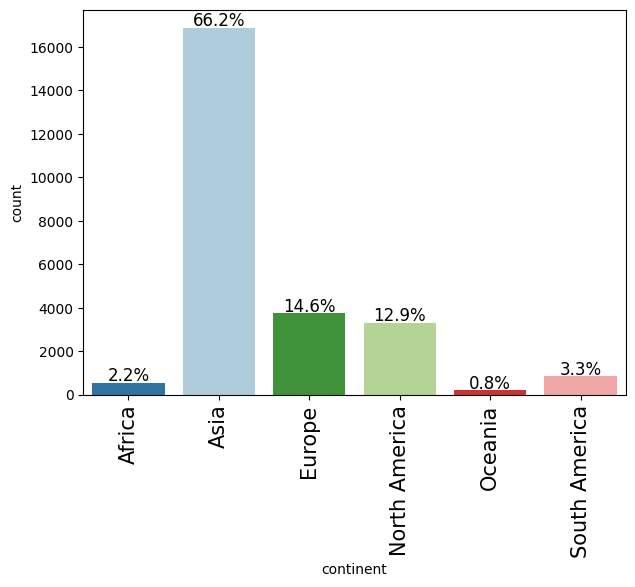

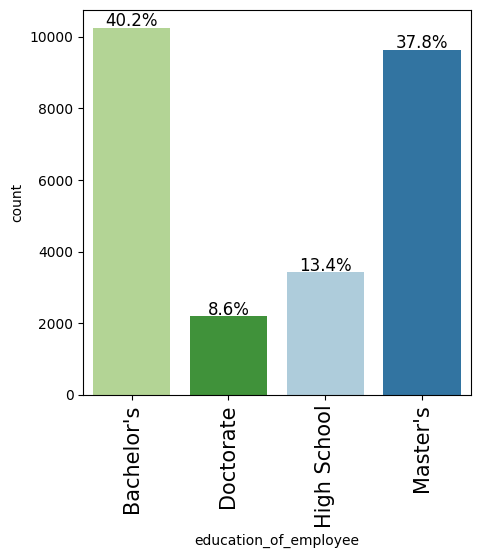

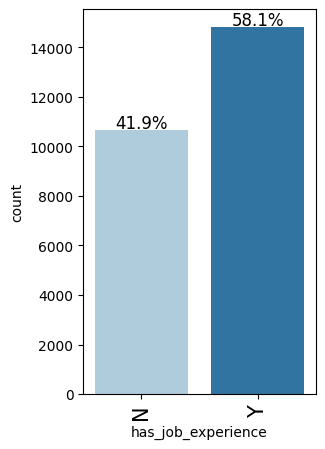

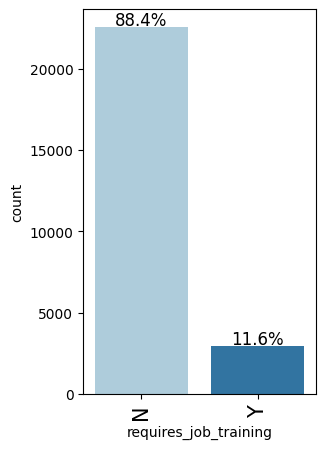

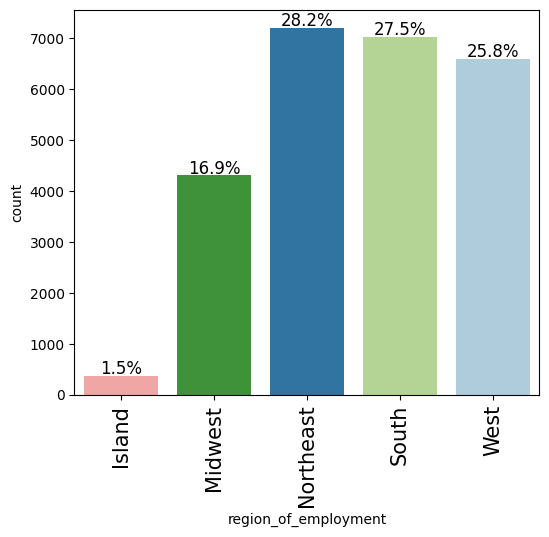

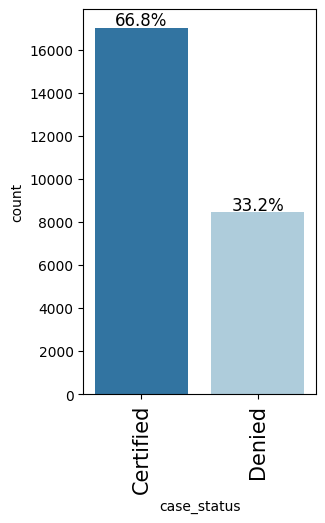

In [9]:
for col in ["continent", "education_of_employee", "has_job_experience",
            "requires_job_training", "region_of_employment", "case_status"]:
    labeled_barplot(data, col, perc=True)

**Continent:**
* 66% of all applicants are from Asian countries, followed by Europe and North America with 15% and 13% respectively.

**Education of Employee:**
* Bachelor's 40% (~11,000 applicants)
* Master's 38% (~9,500 applicants)
* High School 13% (~3,800 applicants)
* Doctorate 9% (~2,200 applicants)

**Job Experience:**
* 58% of employees have job experience
* 42% of employees do not have job experience

**Requires Job Training:**
* 88% of applicants do not require job training

**Region of Employment:**
Similar and expected percentages and regions:
* Northeast with 28% (7100)
* South with 27.5% (7000)
* West with 26% (6600)
Midwest and Island (Virgin?) regions round out the regions with 17% and 1.5%

**Case Status (Target):**
* 67% were certified
* 33% were denied

## 3. Preprocessing

All transforms are encapsulated in `src/preprocessing.preprocess()`.

In [10]:
data = preprocess(data)
data.info()
data.head()

<class 'pandas.DataFrame'>
RangeIndex: 25480 entries, 0 to 25479
Data columns (total 11 columns):
 #   Column                 Non-Null Count  Dtype   
---  ------                 --------------  -----   
 0   continent              25480 non-null  str     
 1   education_of_employee  25480 non-null  int64   
 2   has_job_experience     25480 non-null  str     
 3   requires_job_training  25480 non-null  str     
 4   no_of_employees        25480 non-null  category
 5   yr_of_estab            25480 non-null  category
 6   region_of_employment   25480 non-null  str     
 7   prevailing_wage        25480 non-null  float64 
 8   unit_of_wage           25480 non-null  str     
 9   full_time_position     25480 non-null  str     
 10  case_status            25480 non-null  int64   
dtypes: category(2), float64(1), int64(2), str(6)
memory usage: 1.8 MB


,continent,education_of_employee,has_job_experience,requires_job_training,no_of_employees,yr_of_estab,region_of_employment,prevailing_wage,unit_of_wage,full_time_position,case_status
0,Asia,0,N,N,"(3504.0, 602069.0]","(2005.0, 2016.0]",West,1229413.220,Hour_to_Year,Y,0
1,Asia,2,Y,N,"(2112.0, 3504.0]","(1997.0, 2005.0]",Northeast,83425.650,Year,Y,1
2,Asia,1,N,Y,"(3504.0, 602069.0]","(2005.0, 2016.0]",West,122996.860,Year,Y,0
3,Asia,1,N,N,"(11.999, 1028.0]","(1799.999, 1976.0]",West,83434.030,Year,Y,0
4,Africa,2,Y,N,"(1028.0, 2112.0]","(1997.0, 2005.0]",South,149907.390,Year,Y,1


## 4. Bivariate EDA — Features vs Target

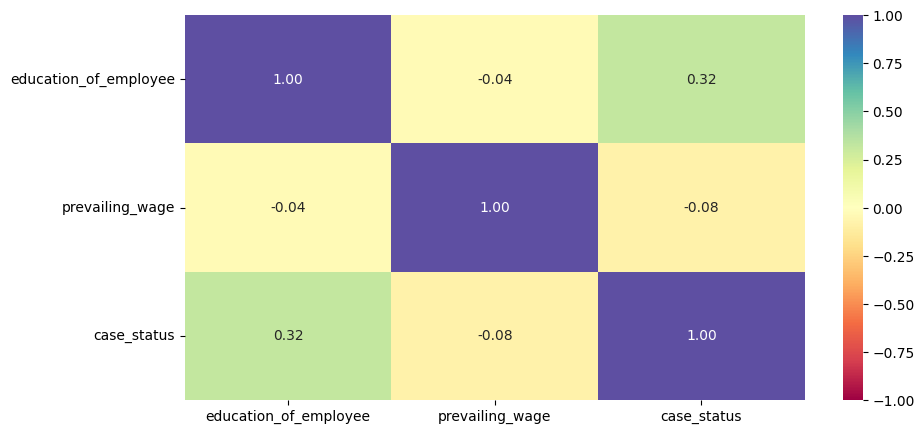

In [11]:
# Correlation heatmap (numeric features)
cols_num = data.select_dtypes(include=np.number).columns.tolist()
plt.figure(figsize=(10, 5))
sns.heatmap(data[cols_num].corr(), annot=True, vmin=-1, vmax=1, fmt=".2f", cmap="Spectral")
plt.show()

* No strong correlation among the numeric columns

#### Does higher education increase the chances of visa certification for well-paid jobs abroad?

case_status               0      1    All
education_of_employee                    
All                    8462  17018  25480
1                      3867   6367  10234
0                      2256   1164   3420
2                      2059   7575   9634
3                       280   1912   2192
------------------------------------------------------------------------------------------------------------------------


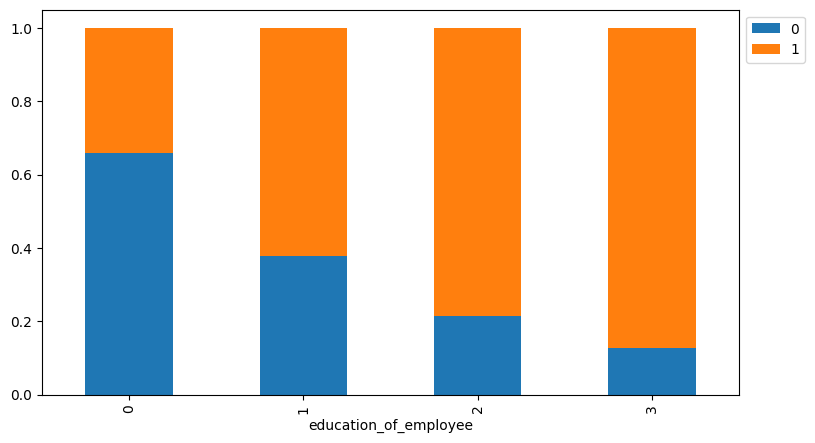

In [12]:
stacked_barplot(data, "education_of_employee", "case_status")

* The higher the education of the employee, the higher the certification rate.

#### How does visa status vary across different continents?

case_status       0      1    All
continent                        
All            8462  17018  25480
Asia           5849  11012  16861
North America  1255   2037   3292
Europe          775   2957   3732
South America   359    493    852
Africa          154    397    551
Oceania          70    122    192
------------------------------------------------------------------------------------------------------------------------


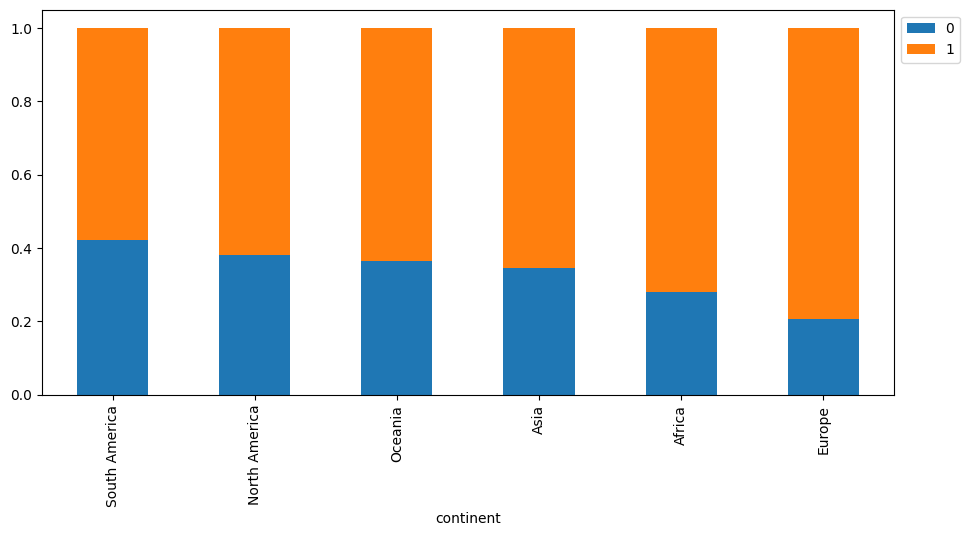

In [13]:
stacked_barplot(data, "continent", "case_status")

* Asia was denied and certified the most in count. This is expected given that 66% of all applicants originate from Asia.
* Asia approval numbers are 11,012 / 16,861 (~65% certification rate)
* Next is Europe with approval numbers of 2,957 / 3,732
* Europe had the greatest percentage approval rate at approximately 75%. Africa is next with about 65%.
* North American applicants (Canada/Mexico) had the highest denial rate at ~61%, despite representing only 13% of applicants. This is notable given their geographic proximity to the US labor market.

#### Does having prior work experience influence the chances of visa certification for career opportunities abroad?

case_status            0      1    All
has_job_experience                    
All                 8462  17018  25480
N                   4684   5994  10678
Y                   3778  11024  14802
------------------------------------------------------------------------------------------------------------------------


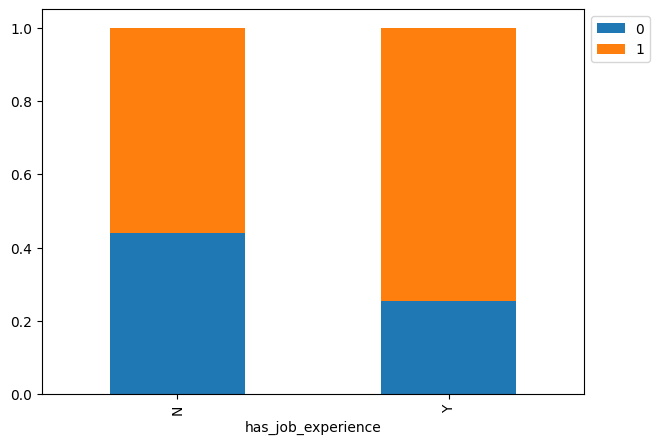

In [14]:
stacked_barplot(data, "has_job_experience", "case_status")

* Prior job experience has a stronger association with visa certification
* Applicants without job experience have only a slightly better than 50% chance of being certified

#### Does the unit of prevailing wage (Hourly, Weekly, etc.) have any impact on the likelihood of visa application certification?

case_status       0      1    All
unit_of_wage                     
All            8462  17018  25480
Year           6915  16047  22962
Hour_to_Year   1410    747   2157
Week_to_Year    103    169    272
Month_to_Year    34     55     89
------------------------------------------------------------------------------------------------------------------------


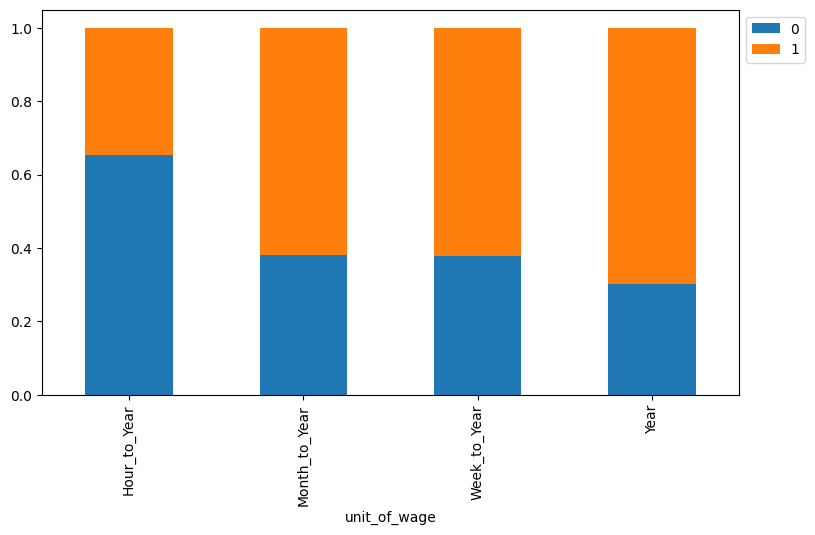

In [15]:
stacked_barplot(data, "unit_of_wage", "case_status")

* Yearly wages have higher certifications though the data is skewed towards yearly units.

#### Does visa status vary with changes in the prevailing wage set to protect both local talent and foreign workers?

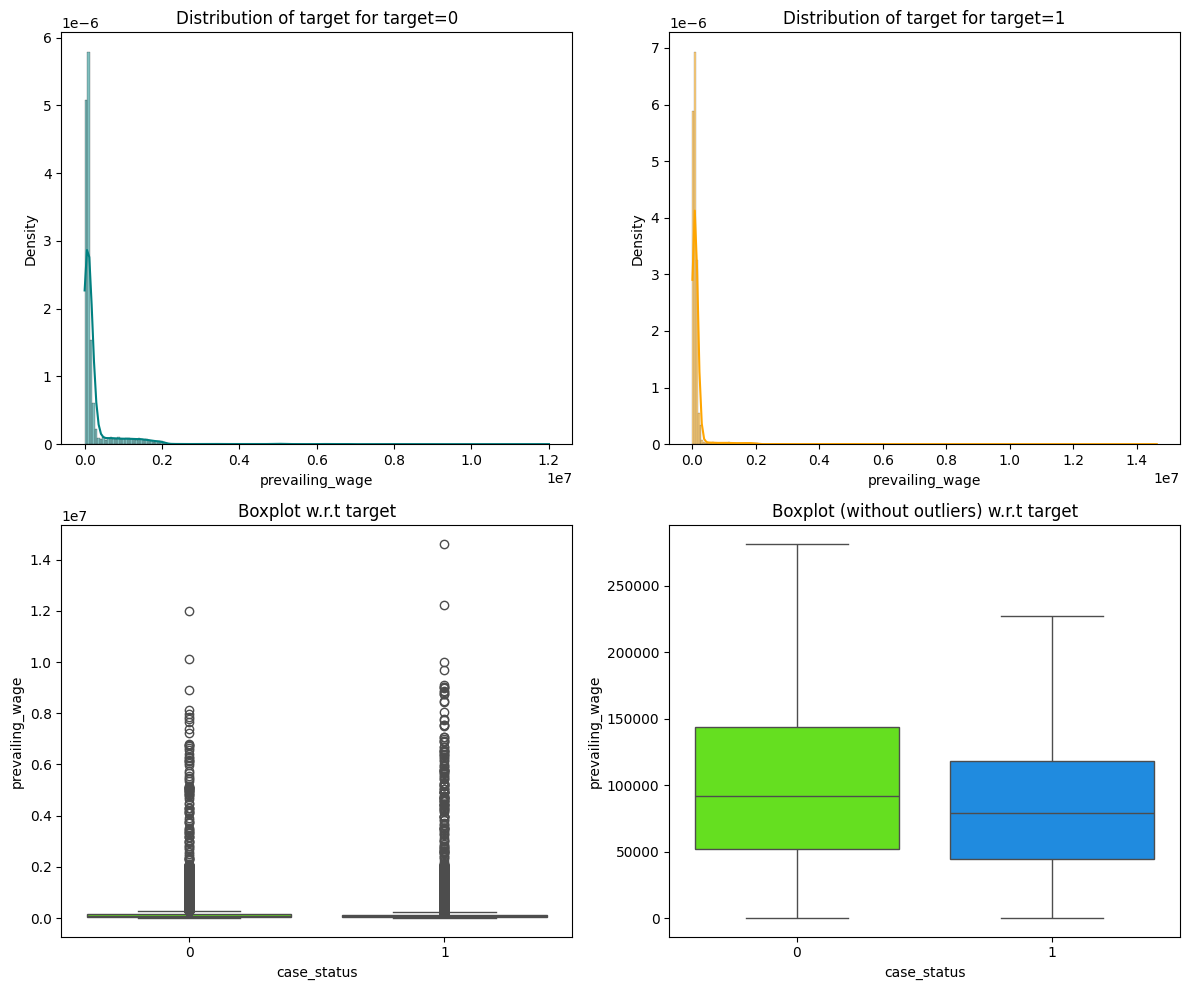

In [16]:
distribution_plot_wrt_target(data, "prevailing_wage", "case_status")

* Very similar certification when compared to prevailing wages though lighly higher certification with higher prevailing wages

#### Is the prevailing wage consistent across all regions of the US?

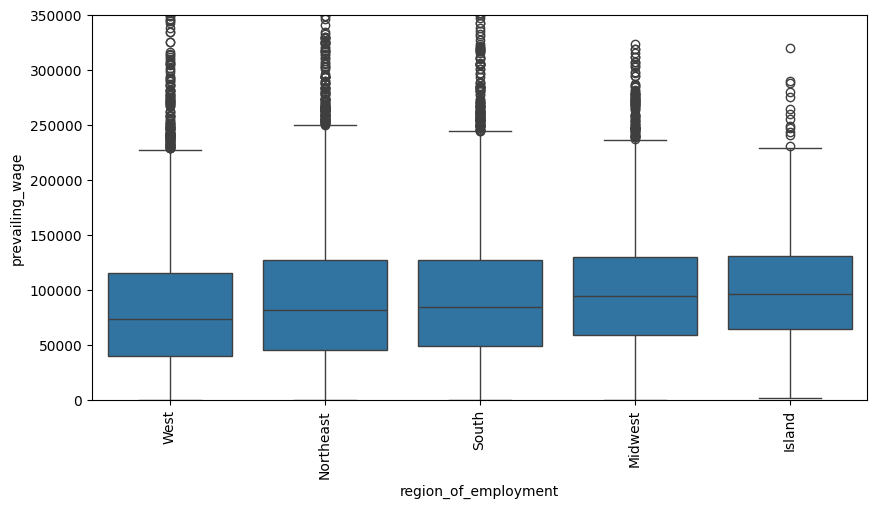

In [17]:
plt.figure(figsize=(10, 5))
plt.ylim(0, 350000)
sns.boxplot(data=data, x="region_of_employment", y="prevailing_wage")
plt.xticks(rotation=90)
plt.show()

* The midwest and island regions have a higher prevailing wage than the other regions

### Outlier Check

* `Prevailing Wages` - Though there are outliers for prevailing wages, many of the outliers were previously certified. There are many reasons for high wages and people with lower education to be paid a higher wage.
* `Year Business Established` - There are many stable companies from the 1800 around in the present age.

## 5. Train / Validation / Test Split

60 % train | 20 % validation | 20 % test (stratified)

In [18]:
X = data.drop(columns=["case_status"])
y = data["case_status"]

X_temp, X_test, y_temp, y_test = train_test_split(
    X, y, test_size=0.2, random_state=1, stratify=y
)
X_train, X_val, y_train, y_val = train_test_split(
    X_temp, y_temp, test_size=0.25, random_state=1, stratify=y_temp
)

print(f"Train: {X_train.shape[0]:,}  Val: {X_val.shape[0]:,}  Test: {X_test.shape[0]:,}")

Train: 15,288  Val: 5,096  Test: 5,096


In [19]:
X_train, X_val, X_test = encode_features(X_train, X_val, X_test)
print("Encoded shapes:", X_train.shape, X_val.shape, X_test.shape)
print("Columns:", X_train.columns.tolist())

Encoded shapes: (15288, 23) (5096, 23) (5096, 23)
Columns: ['education_of_employee', 'prevailing_wage', 'continent_Asia', 'continent_Europe', 'continent_North_America', 'continent_Oceania', 'continent_South_America', 'has_job_experience_Y', 'requires_job_training_Y', 'no_of_employees__1028_0__2112_0_', 'no_of_employees__2112_0__3504_0_', 'no_of_employees__3504_0__602069_0_', 'yr_of_estab__1976_0__1997_0_', 'yr_of_estab__1997_0__2005_0_', 'yr_of_estab__2005_0__2016_0_', 'region_of_employment_Midwest', 'region_of_employment_Northeast', 'region_of_employment_South', 'region_of_employment_West', 'unit_of_wage_Month_to_Year', 'unit_of_wage_Week_to_Year', 'unit_of_wage_Year', 'full_time_position_Y']


## 6. Baseline Model Comparison (Untuned)

Evaluate six classifiers across three sampling strategies to pick which algorithm and strategy to tune.

In [20]:
# ── Original data ──
models_orig = get_base_models()
train_and_compare(models_orig, X_train, y_train, X_val, y_val, label="Original Data")


  Original Data
Model                    Train F1     Val F1        Gap
-------------------------------------------------------
Bagging                    0.9879     0.7677     0.2203
Random Forest              1.0000     0.7702     0.2298
GBM                        0.8277     0.8260     0.0017
AdaBoost                   0.8187     0.8171     0.0016
Decision Tree              1.0000     0.7459     0.2541
XGBoost                    0.8729     0.8101     0.0628


[('Bagging',
  BaggingClassifier(estimator=DecisionTreeClassifier(class_weight='balanced',
                                                     random_state=1),
                    random_state=1)),
 ('Random Forest',
  RandomForestClassifier(class_weight='balanced', random_state=1)),
 ('GBM', GradientBoostingClassifier(random_state=1)),
 ('AdaBoost', AdaBoostClassifier(random_state=1)),
 ('Decision Tree',
  DecisionTreeClassifier(class_weight='balanced', random_state=1)),
 ('XGBoost',
  XGBClassifier(base_score=None, booster=None, callbacks=None,
                colsample_bylevel=None, colsample_bynode=None,
                colsample_bytree=None, device=None, early_stopping_rounds=None,
                enable_categorical=False, eval_metric='logloss',
                feature_types=None, feature_weights=None, gamma=None,
                grow_policy=None, importance_type=None,
                interaction_constraints=None, learning_rate=None, max_bin=None,
                max_cat_threshol

### Model Evaluation Criterion

- Predicting a non-qualified visa is certified - Increased processing time of candidates who will eventually get denied. GDP impact of more fiscal expenses
- Denying a qualified visa candidate - Less talent for companies. Likely to increase visa requests and ultimately GDP impact of less potential foreign contribution
- We want to focus on reducing False Positive (FP) to benefit the Visa processing offices, so increase Precision. We also want to reduce False Negative to benefit the entire system which allows more qualified visa applicants.
- Given both arguments above, we will ultimately focus on F1 Score.


### Original Data — Findings

Original Data Findings:
- Bagging: Training Score: 0.99, Validation Score: 0.76 - overfitting
- Random forest: Training Score: 1.00, Validation Score: 0.76 - overfitting
- GBM: Training Score: 0.8254, Validation Score: 0.8199 - Good*
- Adaboost: Training Score: 0.8160, Validation Score: 0.8159 - Good
- dtree: Training Score: 1.0000, Validation Score: 0.7429 - Overfitting
- Xgboost: Training Score: 0.8750, Validation Score: 0.8148 - Okay

Best:
*   GBM with original data
*   Adaboost with original data
*   XGBoost is a close 3rd but we will focus on the first two.




In [21]:
# ── SMOTE oversampling ──
X_train_over, y_train_over = apply_smote(X_train, y_train)

models_over = get_base_models()
train_and_compare(models_over, X_train_over, y_train_over, X_val, y_val, label="SMOTE Oversampling")

Before SMOTE — class 1: 10,210  class 0: 5,078
After SMOTE  — class 1: 10,210  class 0: 10,210

  SMOTE Oversampling
Model                    Train F1     Val F1        Gap
-------------------------------------------------------
Bagging                    0.9851     0.7676     0.2175
Random Forest              1.0000     0.7679     0.2320
GBM                        0.8244     0.8222     0.0021
AdaBoost                   0.8124     0.8170    -0.0046
Decision Tree              1.0000     0.7466     0.2534
XGBoost                    0.8665     0.8146     0.0519


[('Bagging',
  BaggingClassifier(estimator=DecisionTreeClassifier(class_weight='balanced',
                                                     random_state=1),
                    random_state=1)),
 ('Random Forest',
  RandomForestClassifier(class_weight='balanced', random_state=1)),
 ('GBM', GradientBoostingClassifier(random_state=1)),
 ('AdaBoost', AdaBoostClassifier(random_state=1)),
 ('Decision Tree',
  DecisionTreeClassifier(class_weight='balanced', random_state=1)),
 ('XGBoost',
  XGBClassifier(base_score=None, booster=None, callbacks=None,
                colsample_bylevel=None, colsample_bynode=None,
                colsample_bytree=None, device=None, early_stopping_rounds=None,
                enable_categorical=False, eval_metric='logloss',
                feature_types=None, feature_weights=None, gamma=None,
                grow_policy=None, importance_type=None,
                interaction_constraints=None, learning_rate=None, max_bin=None,
                max_cat_threshol

### SMOTE Oversampling — Findings

* Using SMOTE, we oversampled the Denied (0) minority class from 5,078 to 10,210 to match the Certified (1) majority class, achieving a 1:1 class ratio in the training set.


Observation with oversampled data
- Bagging: Training Score: 0.9856, Validation Score: 0.7653 - overfitting
- Random forest: Training Score: 1.0, Validation Score: 0.7704 - overfitting
- GBM: Training Score: 0.8215, Validation Score: 0.8187 - good
- Adaboost: Training Score: 0.8041, Validation Score: 0.8063 - good
- dtree: Training Score: 1.0000, Validation Score: 0.7402 - overfitting
- Xgboost: Training Score: 0.8667, Validation Score: 0.8144 - okay

Best:
- GBM with OverSampling
- Adaboost

In [22]:
# ── Random undersampling ──
X_train_un, y_train_un = apply_undersampling(X_train, y_train)

models_un = get_base_models()
train_and_compare(models_un, X_train_un, y_train_un, X_val, y_val, label="Random Undersampling")

Before Under — class 1: 10,210  class 0: 5,078
After Under  — class 1: 5,078  class 0: 5,078

  Random Undersampling
Model                    Train F1     Val F1        Gap
-------------------------------------------------------
Bagging                    0.9750     0.6923     0.2827
Random Forest              0.9999     0.7105     0.2894
GBM                        0.7283     0.7796    -0.0513
AdaBoost                   0.6910     0.7615    -0.0705
Decision Tree              1.0000     0.7000     0.3000
XGBoost                    0.8259     0.7524     0.0734


[('Bagging',
  BaggingClassifier(estimator=DecisionTreeClassifier(class_weight='balanced',
                                                     random_state=1),
                    random_state=1)),
 ('Random Forest',
  RandomForestClassifier(class_weight='balanced', random_state=1)),
 ('GBM', GradientBoostingClassifier(random_state=1)),
 ('AdaBoost', AdaBoostClassifier(random_state=1)),
 ('Decision Tree',
  DecisionTreeClassifier(class_weight='balanced', random_state=1)),
 ('XGBoost',
  XGBClassifier(base_score=None, booster=None, callbacks=None,
                colsample_bylevel=None, colsample_bynode=None,
                colsample_bytree=None, device=None, early_stopping_rounds=None,
                enable_categorical=False, eval_metric='logloss',
                feature_types=None, feature_weights=None, gamma=None,
                grow_policy=None, importance_type=None,
                interaction_constraints=None, learning_rate=None, max_bin=None,
                max_cat_threshol

### Undersampling — Findings

Observation with undersampled data
* Bagging - Train: 0.98 vs Val: 0.69 = overfitting
* Random forest - Train: 1.0 vs Val: 0.71 = overfitting
* GBM: Train: 0.72 vs Val: 0.75 — Validation exceeds Training, which is atypical. This is caused by undersampling distorting the training distribution (fewer majority-class examples make training harder). The model generalizes well to the original distribution but training F1 is not a reliable performance benchmark here.
* AdaBoost: Train: 0.69 vs Val: 0.82 — Same pattern as GBM; validation outperforms training due to undersampling effect.
* Decision Tree: Train: 1.0 vs Val: 0.70 = overfitting
* XGBoost: Train: 0.83 vs Val: 0.75 = okay

UnderSampling Findings:
* GBM
* Adaboost
*   Xgboost with undersampling


## 7. Hyperparameter Tuning

RandomizedSearchCV (wide search) → GridSearchCV (narrow refinement) for GBM and AdaBoost.  
XGBoost uses RandomizedSearchCV only (GridSearch exceeds 2 hours).

All param grids are defined in `configs/model_params.py`.

### Tuning Strategy

Models selected for tuning based on baseline F1 and low train/val gap:
1. GBM with original data
2. AdaBoost with original data
3. GBM with SMOTE oversampling
4. AdaBoost with SMOTE oversampling
5. XGBoost with SMOTE oversampling
6. GBM with undersampling
7. AdaBoost with undersampling
8. XGBoost with undersampling

Each algorithm uses RandomizedSearchCV (wide search) followed by GridSearchCV (narrow refinement). XGBoost uses RandomizedSearchCV only — GridSearchCV exceeds 1.5–2.4 hours.

#### AdaBoost — Tuning Best Practices

**Best practices for hyperparameter tuning in AdaBoost:**

`n_estimators`:

- Start with a specific number (50 is used in general) and increase in steps: 50, 75, 85, 100

- Use fewer estimators (e.g., 50 to 100) if using complex base learners (like deeper decision trees)

- Use more estimators (e.g., 100 to 150) when learning rate is low (e.g., 0.1 or lower)

- Avoid very high values unless performance keeps improving on validation

`learning_rate`:

- Common values to try: 1.0, 0.5, 0.1, 0.01

- Use 1.0 for faster training, suitable for fewer estimators

- Use 0.1 or 0.01 when using more estimators to improve generalization

- Avoid very small values (< 0.01) unless you plan to use many estimators (e.g., >500) and have sufficient data


---

#### Gradient Boosting — Tuning Best Practices

**Best practices for hyperparameter tuning in Gradient Boosting:**

`n_estimators`:

* Start with 100 (default) and increase: 100, 200, 300, 500
* Typically, higher values lead to better performance, but they also increase training time
* Use 200–500 for larger datasets or complex problems
* Monitor validation performance to avoid overfitting, as too many estimators can degrade generalization


`learning_rate`:

* Common values to try: 0.1, 0.05, 0.01, 0.005
* Use lower values (e.g., 0.01 or 0.005) if you are using many estimators (e.g., > 200)
* Higher learning rates (e.g., 0.1) can be used with fewer estimators for faster convergence
* Always balance the learning rate with `n_estimators` to prevent overfitting or underfitting


`subsample`:

* Common values: 0.7, 0.8, 0.9, 1.0
* Use a value between `0.7` and `0.9` for improved generalization by introducing randomness
* `1.0` uses the full dataset for each boosting round, potentially leading to overfitting
* Reducing `subsample` can help reduce overfitting, especially in smaller datasets


`max_features`:

* Common values: `"sqrt"`, `"log2"`, or float (e.g., `0.3`, `0.5`)
* `"sqrt"` (default) works well for classification tasks
* Lower values (e.g., `0.3`) help reduce overfitting by limiting the number of features considered at each split

---

#### XGBoost — Tuning Best Practices

**Best practices for hyperparameter tuning in XGBoost:**

`n_estimators`:

* Start with 50 and increase in steps: 50,75,100,125.
* Use more estimators (e.g., 150-250) when using lower learning rates
* Monitor validation performance
* High values improve learning but increase training time

`subsample`:

* Common values: 0.5, 0.7, 0.8, 1.0
* Use `0.7–0.9` to introduce randomness and reduce overfitting
* `1.0` uses the full dataset in each boosting round; may overfit on small datasets
* Values < 0.5 are rarely useful unless dataset is very large

`gamma`:

* Try values: 0 (default), 1, 3, 5, 8
* Controls minimum loss reduction needed for a split
* Higher values make the algorithm more conservative (i.e., fewer splits)
* Use values > 0 to regularize and reduce overfitting, especially on noisy data


`colsample_bytree`:

* Try values: 0.3, 0.5, 0.7, 1.0
* Fraction of features sampled per tree
* Lower values (e.g., 0.3 or 0.5) increase randomness and improve generalization
* Use `1.0` when you want all features considered for every tree


`colsample_bylevel`:

* Try values: 0.3, 0.5, 0.7, 1.0
* Fraction of features sampled at each tree level (i.e., per split depth)
* Lower values help in regularization and reducing overfitting
* Often used in combination with `colsample_bytree` for fine control over feature sampling

---

### 7.1 GBM — Original Data

In [23]:
%%time
gbc_orig_random = tune_random(
    GradientBoostingClassifier(random_state=1),
    GBM_PARAMS["random"],
    X_train, y_train,
    n_iter=GBM_PARAMS["n_iter"], cv=GBM_PARAMS["cv"],
)

Fitting 5 folds for each of 50 candidates, totalling 250 fits
Best params: {'subsample': 0.8, 'n_estimators': 100, 'max_features': 0.5, 'learning_rate': 0.05, 'init': AdaBoostClassifier(random_state=1)}  CV F1: 0.8242
CPU times: user 2.85 s, sys: 1.69 s, total: 4.54 s
Wall time: 42.8 s


In [24]:
%%time
gbc_orig_tuned = tune_grid(
    GradientBoostingClassifier(random_state=1),
    GBM_PARAMS["grid"],
    X_train, y_train,
    cv=GBM_PARAMS["cv"],
)

Fitting 5 folds for each of 432 candidates, totalling 2160 fits
Best params: {'init': AdaBoostClassifier(random_state=1), 'learning_rate': 0.05, 'max_features': 0.7, 'n_estimators': 150, 'subsample': 0.8}  CV F1: 0.8244
CPU times: user 18.5 s, sys: 16.5 s, total: 35 s
Wall time: 6min 13s


**GBM — Original Data:** GridSearchCV selected over RandomizedSearchCV. Best estimator saved as `gbc_orig_tuned` and added to the model registry.

### 7.2 AdaBoost — Original Data

In [25]:
%%time
abc_orig_random = tune_random(
    AdaBoostClassifier(random_state=1),
    ADA_PARAMS["random"],
    X_train, y_train,
    n_iter=ADA_PARAMS["n_iter"], cv=ADA_PARAMS["cv"],
)

Fitting 5 folds for each of 30 candidates, totalling 150 fits
Best params: {'n_estimators': 100, 'learning_rate': 0.1, 'estimator': DecisionTreeClassifier(max_depth=4, random_state=1)}  CV F1: 0.8224
CPU times: user 3.3 s, sys: 700 ms, total: 4.01 s
Wall time: 36.5 s


In [26]:
%%time
abc_orig_tuned = tune_grid(
    AdaBoostClassifier(random_state=1),
    ADA_PARAMS["grid"],
    X_train, y_train,
    cv=ADA_PARAMS["cv"],
)

Fitting 5 folds for each of 144 candidates, totalling 720 fits
Best params: {'estimator': DecisionTreeClassifier(max_depth=4, random_state=1), 'learning_rate': 0.1, 'n_estimators': 95}  CV F1: 0.8224
CPU times: user 6.63 s, sys: 3.81 s, total: 10.4 s
Wall time: 2min 51s


**AdaBoost — Original Data:** GridSearchCV result used. Best estimator saved as `abc_orig_tuned` and added to the model registry.

### 7.3 GBM — SMOTE Oversampling

In [27]:
%%time
gbc_over_random = tune_random(
    GradientBoostingClassifier(random_state=1),
    GBM_PARAMS_WIDE["random"],
    X_train_over, y_train_over,
    n_iter=GBM_PARAMS_WIDE["n_iter"], cv=GBM_PARAMS_WIDE["cv"],
)

Fitting 5 folds for each of 50 candidates, totalling 250 fits
Best params: {'subsample': 0.9, 'n_estimators': 150, 'max_features': 0.3, 'learning_rate': 0.1, 'init': AdaBoostClassifier(random_state=1)}  CV F1: 0.8206
CPU times: user 4.88 s, sys: 2.27 s, total: 7.15 s
Wall time: 1min 13s


In [28]:
%%time
gbc_over_tuned = tune_grid(
    GradientBoostingClassifier(random_state=1),
    GBM_PARAMS_WIDE["grid"],
    X_train_over, y_train_over,
    cv=GBM_PARAMS_WIDE["cv"],
)

Fitting 5 folds for each of 384 candidates, totalling 1920 fits
Best params: {'init': AdaBoostClassifier(random_state=1), 'learning_rate': 0.1, 'max_features': 0.3, 'n_estimators': 250, 'subsample': 0.9}  CV F1: 0.8209
CPU times: user 19.9 s, sys: 17.4 s, total: 37.3 s
Wall time: 9min 7s


**GBM — SMOTE Oversampling:** GridSearchCV result used. Best estimator saved as `gbc_over_tuned` and added to the model registry.

### 7.4 AdaBoost — SMOTE Oversampling

In [29]:
%%time
abc_over_random = tune_random(
    AdaBoostClassifier(random_state=1),
    ADA_PARAMS["random"],
    X_train_over, y_train_over,
    n_iter=ADA_PARAMS["n_iter"], cv=ADA_PARAMS["cv"],
)

Fitting 5 folds for each of 30 candidates, totalling 150 fits
Best params: {'n_estimators': 85, 'learning_rate': 0.5, 'estimator': DecisionTreeClassifier(max_depth=4, random_state=1)}  CV F1: 0.8144
CPU times: user 4.87 s, sys: 1.32 s, total: 6.19 s
Wall time: 1min 12s


In [30]:
%%time
abc_over_tuned = tune_grid(
    AdaBoostClassifier(random_state=1),
    ADA_PARAMS["grid"],
    X_train_over, y_train_over,
    cv=ADA_PARAMS["cv"],
)

Fitting 5 folds for each of 144 candidates, totalling 720 fits
Best params: {'estimator': DecisionTreeClassifier(max_depth=4, random_state=1), 'learning_rate': 1.0, 'n_estimators': 95}  CV F1: 0.8154
CPU times: user 9.44 s, sys: 5.87 s, total: 15.3 s
Wall time: 5min 21s


**AdaBoost — SMOTE Oversampling:** GridSearchCV result used. Best estimator saved as `abc_over_tuned` and added to the model registry.

### 7.5 XGBoost — SMOTE Oversampling

In [31]:
%%time
xgb_over_tuned = tune_random(
    XGBClassifier(random_state=1, eval_metric="logloss"),
    XGB_PARAMS["random"],
    X_train_over, y_train_over,
    n_iter=XGB_PARAMS["n_iter"], cv=XGB_PARAMS["cv"],
)

Fitting 10 folds for each of 50 candidates, totalling 500 fits
Best params: {'subsample': 0.8, 'scale_pos_weight': 2, 'reg_lambda': 10, 'n_estimators': 100, 'max_depth': 4, 'learning_rate': 0.2, 'gamma': 1, 'colsample_bytree': 0.3, 'colsample_bylevel': 0.7}  CV F1: 0.8367
CPU times: user 5.42 s, sys: 4.15 s, total: 9.56 s
Wall time: 23.4 s


**XGBoost — SMOTE Oversampling:** RandomizedSearchCV used — GridSearchCV estimated at 1.5 hours. Best estimator saved as `xgb_over_tuned` and added to the model registry.

### 7.6 GBM — Undersampling

In [32]:
%%time
gbc_un_random = tune_random(
    GradientBoostingClassifier(random_state=1),
    GBM_PARAMS_WIDE["random"],
    X_train_un, y_train_un,
    n_iter=GBM_PARAMS_WIDE["n_iter"], cv=GBM_PARAMS_WIDE["cv"],
)

Fitting 5 folds for each of 50 candidates, totalling 250 fits
Best params: {'subsample': 0.7, 'n_estimators': 275, 'max_features': 0.3, 'learning_rate': 0.05, 'init': AdaBoostClassifier(random_state=1)}  CV F1: 0.7106
CPU times: user 4.17 s, sys: 1.02 s, total: 5.18 s
Wall time: 34.4 s


In [33]:
%%time
gbc_un_tuned = tune_grid(
    GradientBoostingClassifier(random_state=1),
    GBM_PARAMS_WIDE["grid"],
    X_train_un, y_train_un,
    cv=GBM_PARAMS_WIDE["cv"],
)

Fitting 5 folds for each of 384 candidates, totalling 1920 fits
Best params: {'init': AdaBoostClassifier(random_state=1), 'learning_rate': 0.05, 'max_features': 0.3, 'n_estimators': 100, 'subsample': 0.7}  CV F1: 0.7118
CPU times: user 12.1 s, sys: 5.93 s, total: 18 s
Wall time: 3min 46s


**GBM — Undersampling:** GridSearchCV result used. Best estimator saved as `gbc_un_tuned` and added to the model registry.

### 7.7 AdaBoost — Undersampling

In [34]:
%%time
abc_un_random = tune_random(
    AdaBoostClassifier(random_state=1),
    ADA_PARAMS["random"],
    X_train_un, y_train_un,
    n_iter=ADA_PARAMS["n_iter"], cv=ADA_PARAMS["cv"],
)

Fitting 5 folds for each of 30 candidates, totalling 150 fits
Best params: {'n_estimators': 100, 'learning_rate': 0.1, 'estimator': DecisionTreeClassifier(max_depth=3, random_state=1)}  CV F1: 0.7134
CPU times: user 2.22 s, sys: 471 ms, total: 2.69 s
Wall time: 24.9 s


In [35]:
%%time
abc_un_tuned = tune_grid(
    AdaBoostClassifier(random_state=1),
    ADA_PARAMS["grid"],
    X_train_un, y_train_un,
    cv=ADA_PARAMS["cv"],
)

Fitting 5 folds for each of 144 candidates, totalling 720 fits
Best params: {'estimator': DecisionTreeClassifier(max_depth=2, random_state=1), 'learning_rate': 0.1, 'n_estimators': 65}  CV F1: 0.7164
CPU times: user 4.83 s, sys: 2.49 s, total: 7.32 s
Wall time: 1min 54s


**AdaBoost — Undersampling:** GridSearchCV result used. Best estimator saved as `abc_un_tuned` and added to the model registry.

### 7.8 XGBoost — Undersampling

In [36]:
%%time
xgb_un_tuned = tune_random(
    XGBClassifier(random_state=1, eval_metric="logloss"),
    XGB_PARAMS_UNDER["random"],
    X_train_un, y_train_un,
    n_iter=XGB_PARAMS_UNDER["n_iter"], cv=XGB_PARAMS_UNDER["cv"],
)

Fitting 10 folds for each of 50 candidates, totalling 500 fits
Best params: {'subsample': 1.0, 'scale_pos_weight': 2, 'reg_lambda': 10, 'n_estimators': 125, 'max_depth': 4, 'learning_rate': 0.05, 'gamma': 1, 'colsample_bytree': 1.0, 'colsample_bylevel': 0.3}  CV F1: 0.7374
CPU times: user 3.08 s, sys: 919 ms, total: 4 s
Wall time: 8.75 s


**XGBoost — Undersampling:** RandomizedSearchCV used — GridSearchCV estimated at 2.4 hours. Best estimator saved as `xgb_un_tuned` and added to the model registry.

## 8. Compare All Tuned Models

In [37]:
# Registry: (display_name, fitted_model, X_train_used, y_train_used)
tuned_model_registry = [
    ("GBM Orig",   gbc_orig_tuned, X_train,     y_train),
    ("ADA Orig",   abc_orig_tuned, X_train,     y_train),
    ("GBM Over",   gbc_over_tuned, X_train_over, y_train_over),
    ("ADA Over",   abc_over_tuned, X_train_over, y_train_over),
    ("XGB Over",   xgb_over_tuned, X_train_over, y_train_over),
    ("GBM Under",  gbc_un_tuned,   X_train_un,  y_train_un),
    ("ADA Under",  abc_un_tuned,   X_train_un,  y_train_un),
    ("XGB Under",  xgb_un_tuned,   X_train_un,  y_train_un),
]

results_train = pd.DataFrame()
results_val   = pd.DataFrame()

for name, model, X_tr, y_tr in tuned_model_registry:
    perf_train = model_performance_classification_sklearn(model, X_tr, y_tr)
    perf_val   = model_performance_classification_sklearn(model, X_val, y_val)
    results_train[name] = perf_train.T[0]
    results_val[name]   = perf_val.T[0]

compare_models(results_train, results_val)

=== Train Performance ===


,GBM Orig,ADA Orig,GBM Over,ADA Over,XGB Over,GBM Under,ADA Under,XGB Under
Accuracy,0.756,0.753,0.820,0.813,0.786,0.711,0.704,0.694
Recall,0.879,0.874,0.874,0.867,0.970,0.726,0.745,0.877
Precision,0.782,0.782,0.788,0.783,0.709,0.705,0.688,0.642
F1,0.828,0.825,0.829,0.823,0.819,0.715,0.716,0.742



=== Validation Performance ===


,GBM Orig,ADA Orig,GBM Over,ADA Over,XGB Over,GBM Under,ADA Under,XGB Under
Accuracy,0.754,0.753,0.750,0.739,0.711,0.713,0.720,0.750
Recall,0.875,0.872,0.862,0.859,0.961,0.717,0.740,0.865
Precision,0.783,0.783,0.784,0.775,0.709,0.831,0.822,0.783
F1,0.826,0.825,0.821,0.815,0.816,0.769,0.779,0.822



--- GBM Orig ---


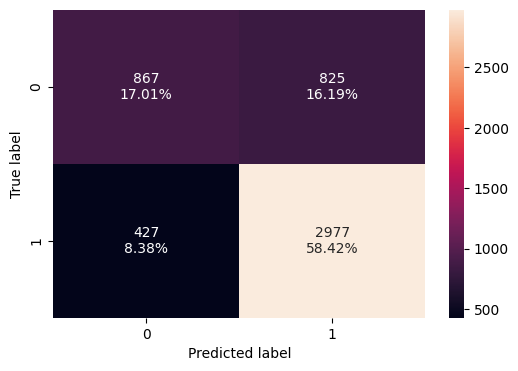


--- ADA Orig ---


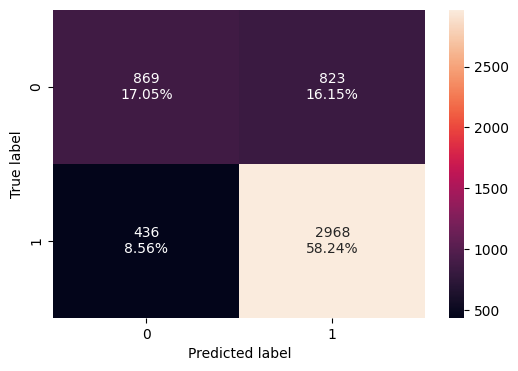


--- GBM Over ---


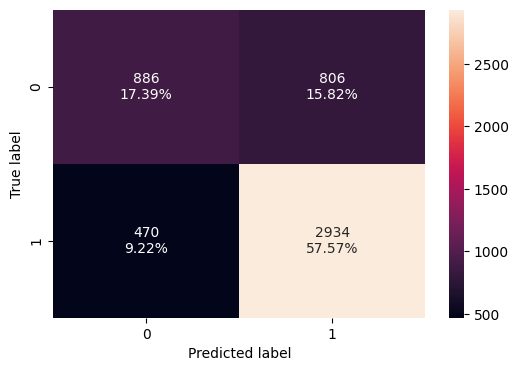


--- ADA Over ---


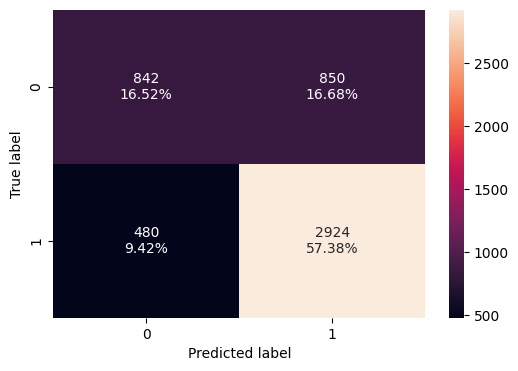


--- XGB Over ---


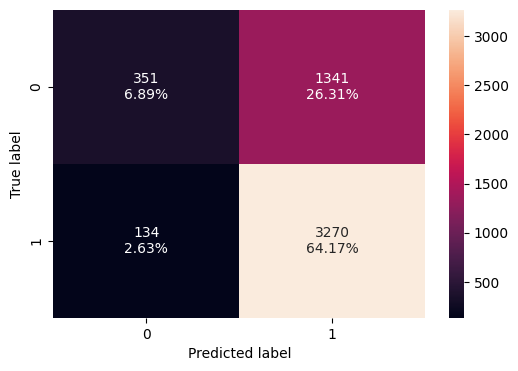


--- GBM Under ---


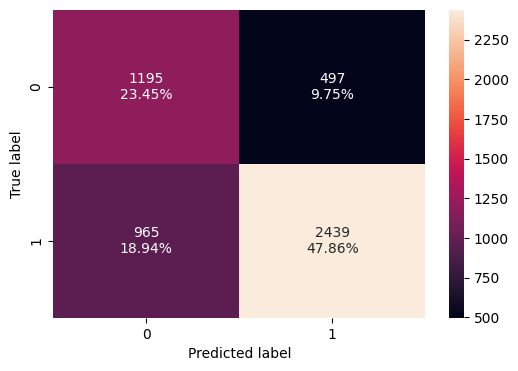


--- ADA Under ---


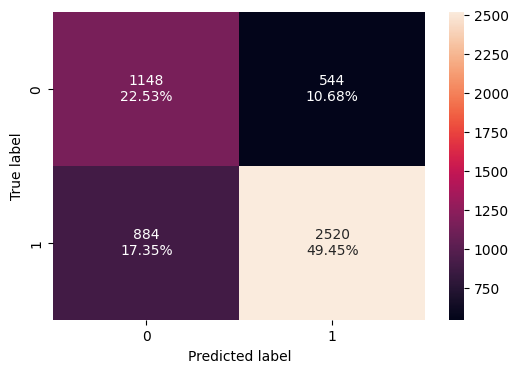


--- XGB Under ---


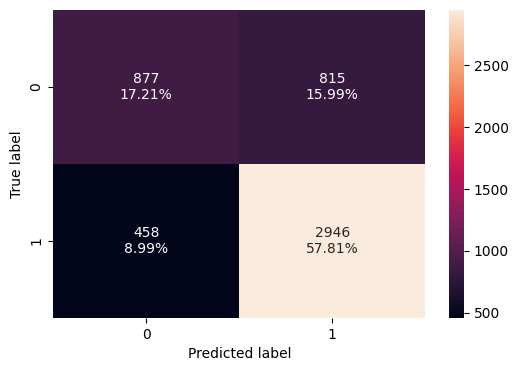

In [38]:
for name, model, _, _ in tuned_model_registry:
    print(f"\n--- {name} ---")
    confusion_matrix_sklearn(model, X_val, y_val)

### Performance Summary — Findings

* GBM Orig and XGB Under are very close in performances
* XGB has a slightly lower F1 score but a higher Precision score which makes it a relevant second choice

## 9. Final Model Selection & Test Evaluation

In [39]:
# Select best model from the registry by validation F1
model_pairs = [(name, model) for name, model, _, _ in tuned_model_registry]
best_name, final_model = select_best_model(results_val, model_pairs, metric="F1")

Best model by validation F1: GBM Orig (0.8263)


**Final Model:** 

The best model by validation F1 is evaluated below on the held-out test set.

In [40]:
# Evaluate on held-out test set
print(f"Test performance — {best_name}")
test_perf = model_performance_classification_sklearn(final_model, X_test, y_test)
test_perf

Test performance — GBM Orig


,Accuracy,Recall,Precision,F1
0,0.742,0.872,0.772,0.819


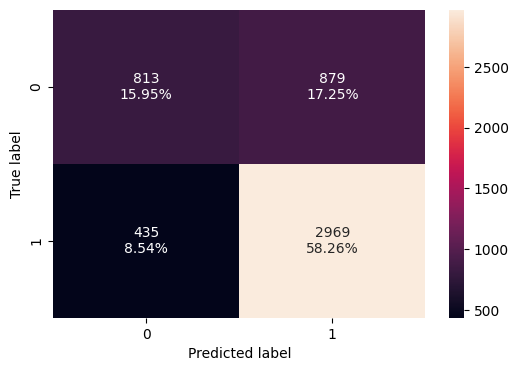

In [41]:
confusion_matrix_sklearn(final_model, X_test, y_test)

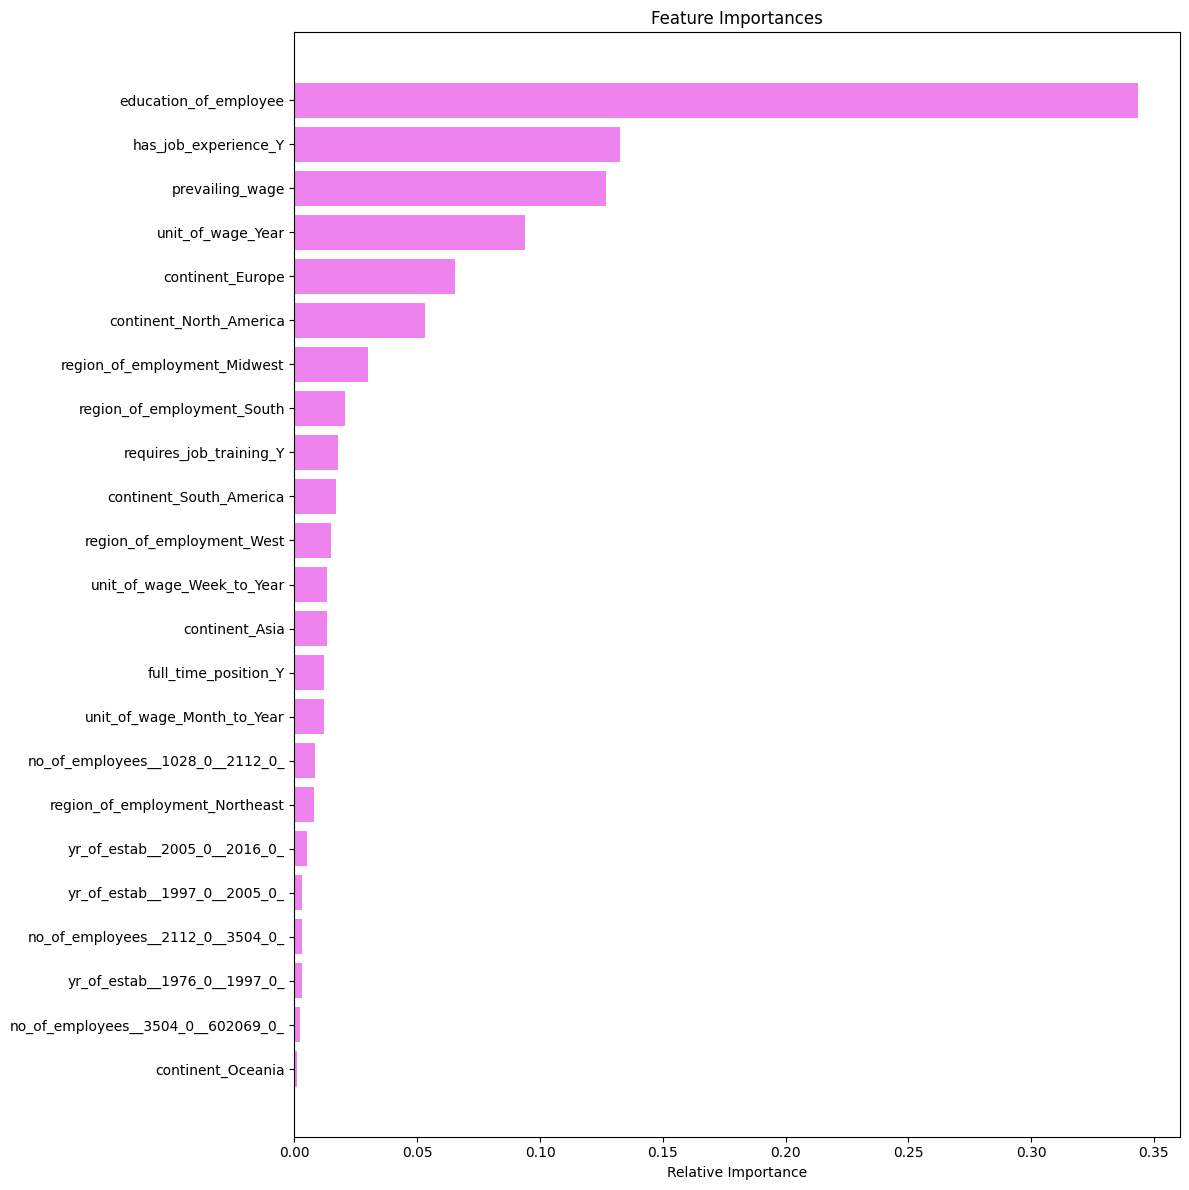

In [42]:
plot_feature_importance(final_model, X_train.columns)

## Actionable Insights and Recommendations

### Insights

* For the OFLC, the most important features are Education, Prior Job Experience, and Annual Salary.
  * Education: Higher education levels strongly correlate with certification. High School applicants with high salaries likely represent entrepreneurs or specialty trade workers — a segment that tends to get certified despite lower formal education.
  * Prior job experience is an expected key driver since US businesses are seeking qualified candidates for hard-to-fill positions.
  * Wages: Higher prevailing wages signal market value and experience. Hourly wage applicants span two distinct segments — lower-wage entry-level workers and high-wage specialty/trade workers — which likely have different certification profiles and should be analyzed separately.
* The prevailing wage distribution is broad, reflecting the diversity of roles and industries represented in the applications.

### Recommendations

* Use the key drivers — education level, job experience, and prevailing wage — to build a fast-track screening profile. Applicants who are degreed, experienced, and earning at or above the regional prevailing wage have the highest likelihood of certification.
  * This benefits OFLC by reducing the processing backlog and improving approval throughput.
  * This benefits businesses by surfacing qualified candidates faster.
* European and African applicants currently show higher certification rates (~75% and ~65% respectively). This appears driven by stronger education and experience profiles within those applicant pools — not geography itself. Screening criteria should focus on these underlying characteristics rather than origin to avoid geographic bias.
* Ensure data validation is in place for wage entry — particularly for hourly workers — to prevent partial-year salaries from distorting the prevailing wage feature. Normalizing to annual salary at point of collection is preferred.
* Create a separate intake and review process for hourly-wage positions, as they represent a distinct applicant segment with different certification dynamics.
* Collect industry/sector data in future applications. The elevated prevailing wages in the Midwest may signal agricultural or food-production industries with specialized labor needs that the current model cannot distinguish.


___

## 10. Save Model

In [43]:
save_model(final_model, "visa-risk.pkl")

Model saved to /Users/shawnedwards/PycharmProjects/AIClass/EasyVisa/models/visa-risk.pkl


PosixPath('/Users/shawnedwards/PycharmProjects/AIClass/EasyVisa/models/visa-risk.pkl')